# Order Error Rate

> Measure how often items are recalled at the wrong output position.

An order error occurs when a participant recalls a list item at the wrong output position. The item was on the study list but is produced in a serial position that does not match where it was originally studied. The order error rate curve plots these transposition errors at each study position.

## Workflow

In [1]:
import os
import matplotlib.pyplot as plt
import warnings
from jaxcmr.analyses.order_error_rate import plot_order_error_rate
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data, save_figure

warnings.filterwarnings("ignore")

In [2]:
data_path = "data/RepeatedRecallsKahanaJacobs2000.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
trial_query = "data['listLength'] > 0"
size = 3
confidence_level = 0.95

In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

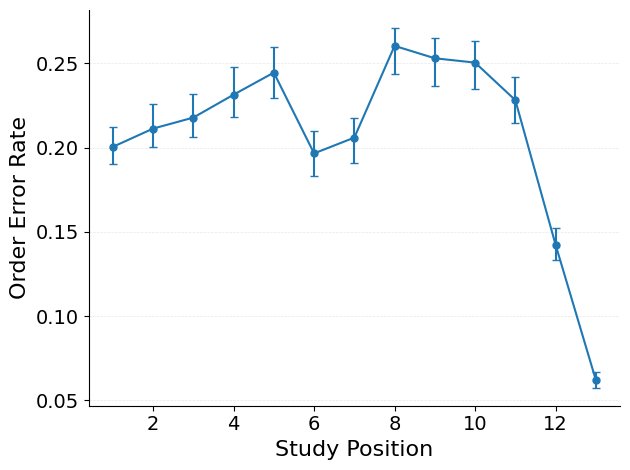

In [4]:
plot_order_error_rate(datasets=data, trial_masks=trial_mask, size=size, confidence_level=confidence_level)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)

## Interpretation

The x-axis shows study position and the y-axis shows the proportion of recalls of that item that appear at the wrong output position. Key patterns:

- **Higher in the middle**: middle-list items are more prone to transposition errors, consistent with weaker positional encoding.
- **Low at extremes**: primacy and recency items tend to be recalled in the correct output position.

## API Details

### Notebook parameters

- `data_path` — path to an HDF5 file containing a `RecallDataset`.
- `figure_dir` — directory for saving figures.
- `figure_str` — base filename for the saved figure. Leave empty to display without saving.
- `ylim` — y-axis limits as a tuple, or `None` for automatic scaling.
- `trial_query` — a Python expression evaluated against the dataset to select trials.
- `size` — maximum number of study positions a single item can occupy.
- `confidence_level` — confidence level for subject-wise error bars.
